In [36]:
#!pip install lifelines
#!pip install EMP-PY
#!pip install interpret
#!pip install sklearn-genetic-opt
#!pip install seaborn
#!pip install tpot==0.12.2 interpret
#!pip install pygad
#!pip install tensorflow


EDA


In [37]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn import metrics
import time, datetime
from IPython.display import display, Markdown
from sklearn.metrics import precision_score
from sklearn.model_selection import train_test_split
import random

df = pd.read_csv('IBM.csv')

"""
To train the model on only fraction of the dataset :
Just for testing purposes, command the below line to actually train the model properly.

df = df.sample(frac=0.001) # Dataset of  Subsample size 70 .

"""

random_state = 42

# 1. check the number of churners and non-churners

print(df['Churn'].value_counts())


# 2. Drop the customer id column as it is useless.
df.drop(['customerID'], axis=1, inplace=True)



# 3. List the columns that contain "No internet service" to convert this value to "No"
tobe_cleaned_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']



df[tobe_cleaned_cols] = df[tobe_cleaned_cols].replace('No internet service', 'No')

#Also change no phone services class to just no
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')


#Change empty string to 0 and convert object type to numeric(float)

df['TotalCharges'] = df['TotalCharges'].replace(" ",0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])


# 4.Encode Categorical to Numeric

from sklearn.preprocessing import LabelEncoder

#Check which columns are categorical

categorical_columns = df.select_dtypes(include = ['object']).columns


#encode the categorical columns to 0 and 1 .

labelencoder = LabelEncoder()

for column in categorical_columns:
    label = labelencoder.fit_transform(df[column])
    df[column] = label

#Remove Missing values . Set reset_index = True so that old indexes are not persisted (can result in missing indexes if set to false) . Also drop the new indexes.

df = df.dropna().reset_index(drop=True)

#pd.get_dummies() is to create new columns for columns with more than 2 classes (prevents ranking). Useful for Logistic Regression models.

df = pd.get_dummies(df,drop_first= True)


#Get the clv for each customers 

df['customer_value'] = df['MonthlyCharges']*df['tenure'].apply(lambda x : x+1)


x = df.drop(columns ='Churn')
y = df['Churn']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state=random_state)

#customer values (Going to be used later for evaluation)

CLTV = x_test['customer_value'].values

"""
#Added a test,val,test split cause pymoo and other libraries do not support cv . let test set be 20 percent in the previous line if we do not use cv.


x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size = 0.25,random_state=random_state) 

"""



Churn
No     5174
Yes    1869
Name: count, dtype: int64


'\n#Added a test,val,test split cause pymoo and other libraries do not support cv . let test set be 20 percent in the previous line if we do not use cv.\n\n\nx_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size = 0.25,random_state=random_state) \n\n'

COXPHMODEL FOR SURVIVAL ANALYSIS AND EPROFITS METRICS FORMULATION



(4930,) (4930,)


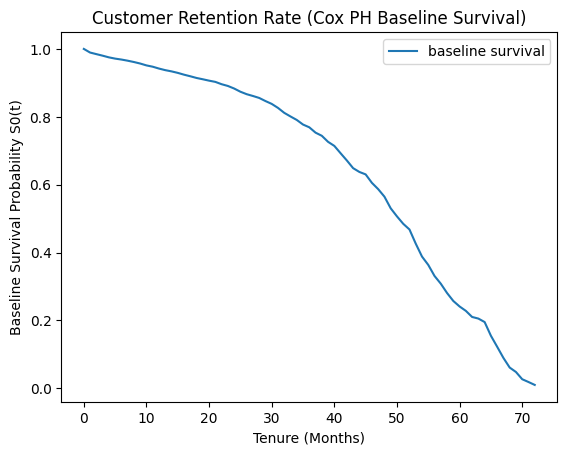

ARR(Δ=1.0): 0.946822
0.9514336233410959
(4930,) (4930,)


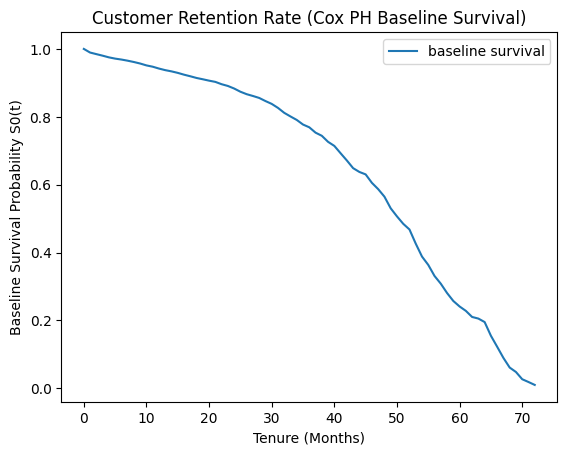

ARR(Δ=1.0): 0.946822
0.9514336233410959


In [38]:
# ===================== IMPORTS =====================
from lifelines import CoxPHFitter                         
from EMP.metrics import empChurn
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import numpy as np

# ===================== CUSTOM METRICS =====================
# Survival Analysis: Cox Proportional Hazards model used to model time-to-churn and estimate retention.

def conditional_retention(retention_fn, tenure, delta=1.0, eps=1e-12):
    ten = np.asarray(tenure, dtype=float)
    S_t = np.asarray(retention_fn(ten), dtype=float)
    S_t_delta = np.asarray(retention_fn(ten + delta), dtype=float)
    return S_t_delta / np.maximum(S_t, eps)


def get_retention_rate(x_train, y_train,tenure, delta=1.0):
    tenure = x_train['tenure'].values.astype(float)
    event_observed = (y_train == 1).astype(int).values

    print(tenure.shape, event_observed.shape)

    # -------------------------------------------------------------------------
    # <<< CHANGED: Cox Proportional Hazards Fitter instead of KaplanMeierFitter
    # Build a small DataFrame with the covariates Cox needs.
    # We include all numeric columns from x_train so Cox can leverage
    # every available predictor (the same information KM ignored).
    cox_df = x_train.copy()
    cox_df['_duration'] = tenure
    cox_df['_event']    = event_observed

    cph = CoxPHFitter(penalizer=0.1)          # penalizer adds L2 regularisation for stability
    cph.fit(cox_df, duration_col='_duration', event_col='_event')
    # -------------------------------------------------------------------------

    # Plot the baseline survival function (analogous to KM curve)
    # <<< CHANGED: plot_baseline_survival instead of kmf.survival_function_
    cph.baseline_survival_.plot()
    plt.title('Customer Retention Rate (Cox PH Baseline Survival)')
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Baseline Survival Probability S0(t)')
    plt.show()

    # -------------------------------------------------------------------------
    # <<< CHANGED: Survival function S(t) now uses Cox baseline survival.
    # We use the BASELINE survival (average/median covariate profile) so that
    # the scalar retention_fn(t) interface is preserved exactly as before.
    baseline_sf = cph.baseline_survival_          # DataFrame indexed by time

    def S(t):
        """Baseline survival probability at time(s) t using Cox PH model."""
        t_arr = np.atleast_1d(np.asarray(t, dtype=float))
        results = []
        for ti in t_arr:
            # Find nearest time in baseline survival index
            idx = baseline_sf.index.searchsorted(ti, side='right') - 1
            idx = max(0, min(idx, len(baseline_sf) - 1))
            results.append(float(baseline_sf.iloc[idx, 0]))
        vals = np.array(results)
        return float(vals[0]) if np.isscalar(t) else vals
    # -------------------------------------------------------------------------

    # Compute TRR_i(Δ) for all training customers and take mean => ARR(Δ)
    trr_train = conditional_retention(S, tenure, delta=delta)
    arr_train = float(np.mean(trr_train))

    print(f'ARR(Δ={delta}): {arr_train:.6f}')
    return arr_train, S


# --- Preserve your variable names exactly ---
DELTA = 1.0  # if tenure is months set 1; if tenure is days set 30
avg_retention_rate, retention_fn = get_retention_rate(x_train, y_train, 'tenure', delta=DELTA)

print(retention_fn(10))  # prints S(10)
f'Average Retention Rate {avg_retention_rate: .2f}'


avg_retention_rate, retention_fn = get_retention_rate(x_train, y_train, 'tenure', delta=DELTA)

print(retention_fn(10))  # prints S(10)
f'Average Retention Rate {avg_retention_rate: .2f}'


def estimate_clv_and_cost_of_intervention(df, i, Profit_Margin=0.3, CPO=0.1):
    # Estimate of CLV: (monthly_revenue * Profit_Margin) / (1 - retention_rate)
    monthly_revenue = df.iloc[i]['customer_value']
    retention_rate = min(0.995, df.iloc[i]['retention_rate'])  # retention rate can never be 1
    clv = (monthly_revenue * Profit_Margin) / (1 - retention_rate)

    # Cost of intervention is CPO * CLV
    base_cost = CPO * clv
    cost_per_offer = base_cost
    return clv, cost_per_offer


# Our Metric calculation function
def _eprofits(df, Profit_Margin, Cost_of_Contact, CPO, verbose=0):
    profits = []
    for i in range(len(df)):
        clv, cost_per_offer = estimate_clv_and_cost_of_intervention(df, i, Profit_Margin, CPO)
        cost_of_contact = max(Cost_of_Contact[0], Cost_of_Contact[1] * cost_per_offer)

        if df.iloc[i]['true'] == 1 and df.iloc[i]['predict'] == df.iloc[i]['true']:  # churners predicted as churners
            profit = clv - cost_per_offer - cost_of_contact
            if verbose:
                print(profit, i, df.iloc[i]['true'], df.iloc[i]['predict'])

        elif df.iloc[i]['predict'] == 1:  # non-churners predicted as churners
            profit = -cost_per_offer - cost_of_contact
            if verbose:
                print(profit, i, df.iloc[i]['true'], df.iloc[i]['predict'])

        else:
            profit = 0  # no intervention
        profits.append(profit)

    return sum(profits)


Profit_Margin = 0.3
Cost_of_Contact = (0, 0.3)
CPO = 0.1


def custom_eprofits_scorer_tenure(
    df, tenure_column, retention_fn, delta,
    Profit_Margin, Cost_of_Contact, CPO, threshold=0.5
):
    def scorer(estimator, X, y):
        y_scores = estimator.predict_proba(X)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

        my_df = df.loc[y.index].copy()

        ten = my_df[tenure_column].astype(float).values
        my_df["retention_rate"] = conditional_retention(retention_fn, ten, delta=delta)

        my_df["true"] = np.asarray(y)
        my_df["predict"] = y_pred
        return _eprofits(my_df, Profit_Margin, Cost_of_Contact, CPO)

    return scorer

def custom_eprofits_scorer_avg(
    df, avg_retention_rate,
    Profit_Margin, Cost_of_Contact, CPO, threshold=0.5
):
    def scorer(estimator, X, y):
        y_scores = estimator.predict_proba(X)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

        my_df = df.loc[y.index].copy()

        # everyone gets the same retention rate ARR(Δ)
        my_df["retention_rate"] = float(avg_retention_rate)

        my_df["true"] = np.asarray(y)
        my_df["predict"] = y_pred
        return _eprofits(my_df, Profit_Margin, Cost_of_Contact, CPO)

    return scorer



# Define the EMP scorer function
def emp_scorer(estimator, X, y):
    # predict probabilities
    y_proba = estimator.predict_proba(X)[:, 1]
    return empChurn(
        y_proba, y,
        alpha=6, beta=14,
        clv=200, d=10, f=1,
        print_output=False,
        return_output=True,
        rounding=None
    ).EMP

# already computed earlier
# avg_retention_rate, retention_fn = get_retention_rate(delta=DELTA)

eprofits_scorer_train_tenure = custom_eprofits_scorer_tenure(
    df=x_train,
    tenure_column='tenure',
    retention_fn=retention_fn,
    delta=DELTA,
    Profit_Margin=Profit_Margin,
    Cost_of_Contact=Cost_of_Contact,
    CPO=CPO,
    threshold=0.5
)

eprofits_scorer_train_avg = custom_eprofits_scorer_avg(
    df=x_train,
    avg_retention_rate=avg_retention_rate,
    Profit_Margin=Profit_Margin,
    Cost_of_Contact=Cost_of_Contact,
    CPO=CPO,
    threshold=0.5
)

SURVIVAL CURVE EXAMPLE FOR A SINGLE CUSTOMER

(4930,) (4930,)
Information for the customer : gender                1.00
SeniorCitizen         0.00
Partner               0.00
Dependents            0.00
tenure                1.00
PhoneService          1.00
MultipleLines         0.00
InternetService       1.00
OnlineSecurity        0.00
OnlineBackup          0.00
DeviceProtection      0.00
TechSupport           0.00
StreamingTV           1.00
StreamingMovies       0.00
Contract              0.00
PaperlessBilling      1.00
PaymentMethod         2.00
MonthlyCharges       80.55
TotalCharges         80.55
customer_value      161.10
_duration             1.00
_event                0.00
Name: 1095, dtype: float64


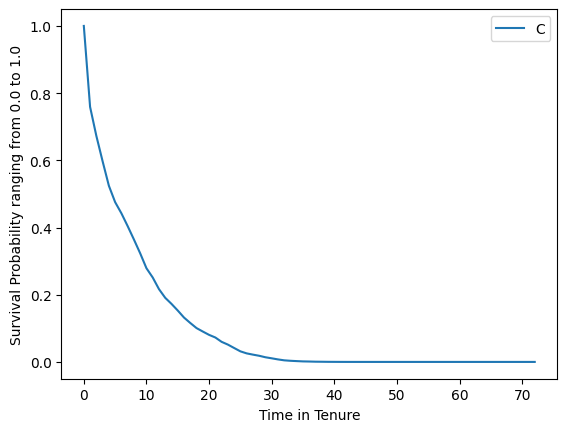

In [39]:
tenure = x_train['tenure'].values.astype(float)
event_observed = (y_train == 1).astype(int).values
print(tenure.shape, event_observed.shape)

cox_df = x_train.copy()
cox_df['_duration'] = tenure
cox_df['_event']    = event_observed
cph = CoxPHFitter(penalizer=0.1)    
cph.fit(cox_df, duration_col='_duration', event_col='_event')

#Survival curve for the first customer in the dataset. 

customer_record = cox_df.iloc[1]
print("Information for the customer :" ,cox_df.iloc[1])
cph.predict_survival_function(customer_record).plot()
plt.xlabel('Time in Tenure')
plt.ylabel('Survival Probability ranging from 0.0 to 1.0')
plt.legend("Customer in the first row")





XGBOOST AND EBM CLASSIFIER TRAINING

In [42]:
import pandas as pd
import sklearn.metrics as metrics
import datetime
import time
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from interpret.glassbox import ExplainableBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Categorical, Integer
# from Metrics_profitability import _eprofits, empChurn
# from Tabnet_training import tabnet_results_by_policy


# ===================== PARAMETER GRIDS =====================
auc_scorer = metrics.make_scorer(metrics.roc_auc_score, needs_proba=True)



cv = 5

#I have used Categorical([values]) to avoid an error. Gemini told me to use Categorical so I do not know if it has messed with the values.
# Please run the code and check for the output.

#Use tuples for the hyperparameter values so that the range of values between (lower,upper) are used.
param_grid_ebm = {
    'learning_rate': Continuous(0.01,0.1),
    'max_bins': Integer(128,256),
    'max_interaction_bins': Integer(16,32),
    'interactions': Integer(10,20)
}
   
param_grid_xgb = {
    'n_estimators': Integer(100,300),
    'learning_rate': Continuous(0.01, 0.2),
    'max_depth': Integer(3, 5),
    'colsample_bytree': Continuous(0.3, 0.7)
}


# ===================== MODEL INITIALIZATION =====================

ebm = ExplainableBoostingClassifier(random_state=random_state)
xgb = xgb.XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='logloss')



Classifiers_with_grids = [
    (ebm, param_grid_ebm, 'ebm'),
    (xgb, param_grid_xgb, 'xgb'),
]



Metrics_to_hypertune_for = {
   "AUC": 'roc_auc',
    "accuracy": metrics.make_scorer(metrics.accuracy_score),
    "f1": metrics.make_scorer(metrics.f1_score),
    "emp": emp_scorer,
    "eprofits_avg": eprofits_scorer_train_avg,
    "eprofits_tenure": eprofits_scorer_train_tenure,
}



def genetic_search(model, param_grid, x, y, cv, scoring, refit=True, verbose=None, _name=None):
    if refit == 'emp':
        n_jobs = 1
    else:
        n_jobs = -1
    now = datetime.datetime.now()
    if _name:
        print(_name.title(), 'at', now)
    else:
        print('At', now)
    start = time.time()

    if verbose:

        #Generally , pop size is more than generations. More population leads to more solutions .
        gs = GASearchCV(estimator=model, param_grid=param_grid, cv=cv,population_size=20,generations=10,tournament_size=3,elitism=True,
                               crossover_probability=0.8,
                               mutation_probability=0.2,algorithm='eaMuPlusLambda',criteria='max',
                          scoring=scoring, refit=refit, n_jobs=n_jobs, verbose=verbose,keep_top_k=2)
    
    else:

        gs = GASearchCV(estimator=model, param_grid=param_grid, cv=cv,population_size=20,generations=10,tournament_size=3,elitism=True,
                               crossover_probability=0.8,
                               mutation_probability=0.2,algorithm='eaMuPlusLambda',criteria='max',
                          scoring=scoring, refit=refit, n_jobs=n_jobs,keep_top_k=2)
    gs.fit(x, y)
    taken = time.time() - start
    gs.fit_time_ = taken  # Creating a custom object for grid search known as fit_time_
    print(f' > done; taken {taken:.2f}')
    return gs

genetic_search_results = {}


def genetic_search_driver(Metrics_to_hypertune_for):
    for Metric_name, Metric_function in Metrics_to_hypertune_for.items():
        _scoring = {Metric_name: Metric_function}
        refit = Metric_name

        print('With scoring', Metric_name)
        for classifier, param_grid, name_of_model in Classifiers_with_grids:
            if name_of_model not in genetic_search_results:
                genetic_search_results[name_of_model] = {}
            genetic_search_results[name_of_model][Metric_name] = genetic_search(
                classifier, param_grid, x_train, y_train, cv, _scoring, refit, verbose=1, _name=name_of_model
            )
    return genetic_search_results

genetic_search_results = genetic_search_driver(Metrics_to_hypertune_for)

With scoring AUC
Ebm at 2026-05-17 21:31:57.737859
gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.844175	0.000720651	0.845202   	0.842689   
1  	40    	0.844985	0.000339638	0.845456   	0.844104   
2  	40    	0.845101	0.000249616	0.845541   	0.844771   
3  	40    	0.845392	0.000233653	0.845807   	0.844996   
4  	40    	0.845502	0.000131904	0.845807   	0.845291   
5  	40    	0.845671	0.000186521	0.845914   	0.845225   
6  	40    	0.845734	0.00010997 	0.845914   	0.845553   
7  	40    	0.845741	9.58082e-05	0.845914   	0.845645   
8  	40    	0.845823	9.48363e-05	0.845914   	0.845674   
9  	40    	0.845889	6.0327e-05 	0.845914   	0.845685   
10 	40    	0.845914	1.94976e-05	0.845977   	0.845855   
 > done; taken 1863.55
Xgb at 2026-05-17 22:03:01.289708
gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.834239	0.00754509 	0.843636   	0.818511   
1  	40    	0.840366	0.00372057 	0.843636   	0.829609   
2  	40    	0.843028	0.00081294 	0.844128   	0.840971

C:\Users\shrey\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:03:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 > done; taken 25.40
With scoring accuracy
Ebm at 2026-05-17 22:03:26.690979
gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.804432	0.000975478	0.805882   	0.802028   
1  	40    	0.805274	0.000439746	0.805882   	0.804462   
2  	40    	0.805385	0.000686291	0.806491   	0.803651   
3  	40    	0.806014	0.000712181	0.807505   	0.804462   
4  	40    	0.806633	0.000521499	0.807505   	0.805477   
5  	40    	0.806734	0.000408711	0.807505   	0.806085   
6  	40    	0.80716 	0.000615578	0.808114   	0.806288   
7  	40    	0.807272	0.000622804	0.808114   	0.805477   
8  	40    	0.807414	0.000519028	0.808114   	0.806694   
9  	40    	0.80785 	0.000333916	0.808114   	0.807099   
10 	40    	0.808083	0.000132624	0.808114   	0.807505   
 > done; taken 2267.53
Xgb at 2026-05-17 22:41:14.221723
gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.795923	0.00490977 	0.80426    	0.787018   
1  	40    	0.799493	0.00493051 	0.804665   	0.788438   
2  	40    	0.802779	0.0015

C:\Users\shrey\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [22:41:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	20    	0.57817	0.00250814 	0.581394   	0.571888   
1  	40    	0.580143	0.00124436 	0.58171    	0.578125   
2  	40    	0.581215	0.00123687 	0.583334   	0.578578   
3  	40    	0.582713	0.00102331 	0.584773   	0.580951   
4  	40    	0.583644	0.000814869	0.584773   	0.582124   
5  	40    	0.584214	0.000637066	0.584773   	0.582897   
6  	40    	0.584399	0.000629495	0.584773   	0.582482   
7  	40    	0.584736	0.00016138 	0.584773   	0.584032   
8  	40    	0.584773	1.11022e-16	0.584773   	0.584773   
9  	40    	0.584773	1.11022e-16	0.584773   	0.584773   
10 	40    	0.584952	0.000518145	0.587118   	0.584773   
 > done; taken 1679.22
Xgb at 2026-05-17 23:09:34.233986
gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.558257	0.028243   	0.576034   	0.448467   
1  	40    	0.572188	0.00354709 	0.577247   	0.56422    
2  	40    	0.575562	0.00332789 	0.580532   	0.570072   
3  	40    	0.576995	0.00230304 	0.580532   	0.572

...

C:\Users\shrey\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [23:32:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 > done; taken 95.53
With scoring eprofits_avg
Ebm at 2026-05-17 23:32:14.762401
gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	20    	492844 	8838.6     	511391     	478476     
1  	40    	496068 	6321.75    	503547     	484098     
2  	40    	499981 	4835.15    	504938     	489542     
3  	40    	503061 	2439.44    	506998     	495150     
4  	40    	503945 	1367.23    	508856     	502405     
5  	40    	504334 	1910.26    	508856     	499883     
6  	40    	505606 	1639.77    	508856     	502708     
7  	40    	506876 	1432.45    	510344     	505435     
8  	40    	506784 	1387.18    	510344     	503033     
9  	40    	507301 	963.421    	510344     	506469     
10 	40    	507276 	1694.25    	508658     	500308     
 > done; taken 2267.37
Xgb at 2026-05-18 00:10:02.132882
gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	20    	483140 	80445.9    	551008     	196555     
1  	40    	524135 	22142.3    	568331     	473018     
2  	40    	542936 	11604.2    	564006

C:\Users\shrey\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [00:13:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


gen	nevals	fitness    	fitness_std	fitness_max	fitness_min
0  	20    	3.65182e+06	35649.2    	3.7385e+06 	3.59325e+06
1  	40    	3.6996e+06 	31505.2    	3.74847e+06	3.64948e+06
2  	40    	3.72221e+06	19091.1    	3.75054e+06	3.69186e+06
3  	40    	3.73983e+06	21658.1    	3.77942e+06	3.7013e+06 
4  	40    	3.75408e+06	16092.9    	3.77942e+06	3.72744e+06
5  	40    	3.75804e+06	13943.7    	3.77942e+06	3.73228e+06
6  	40    	3.76307e+06	12114.7    	3.77942e+06	3.73407e+06
7  	40    	3.76179e+06	19632.5    	3.77942e+06	3.69556e+06
8  	40    	3.76711e+06	9665.1     	3.77942e+06	3.74164e+06
9  	40    	3.76571e+06	10007.4    	3.77942e+06	3.74315e+06
10 	40    	3.77247e+06	13590      	3.79693e+06	3.74315e+06
 > done; taken 2681.97
Xgb at 2026-05-18 00:57:45.489080
gen	nevals	fitness    	fitness_std	fitness_max	fitness_min
0  	20    	3.43387e+06	230025     	3.64114e+06	2.72631e+06
1  	40    	3.57491e+06	57621.7    	3.65219e+06	3.46226e+06
2  	40    	3.6019e+06 	37925.2    	3.66005e+06	3.51512e+06

C:\Users\shrey\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [01:03:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOOST AND EBM PREDICTING BASED ON THE LAST METRIC(E_PROFITS_TENURE) HYPERPARAMETER RESULTS .



In [52]:
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
from scipy import stats



#XGBOOST RESULTS :

xg_boost_y_pred = genetic_search_results['xgb']['eprofits_tenure'].predict(x_test)
xg_boost_y_scores = genetic_search_results['xgb']['eprofits_tenure'].predict_proba(x_test)[:,1]

xg_boost_accuracy = metrics.accuracy_score(xg_boost_y_pred,y_test)
xg_boost_f1 = metrics.f1_score(xg_boost_y_pred,xg_boost_y_pred)
xg_boost_auc = metrics.roc_auc_score(y_test,xg_boost_y_scores)

print("Scores for xgboost ")
print(f"accuracy score : {xg_boost_accuracy} ,f1 : {xg_boost_f1} , auc : {xg_boost_auc} ")


#EBM RESULTS:

y_pred = genetic_search_results['ebm']['eprofits_tenure'].predict(x_test)
y_scores =genetic_search_results['ebm']['eprofits_tenure'].predict_proba(x_test)[:,1]

accuracy = metrics.accuracy_score(y_pred,y_test)
f1 = metrics.f1_score(y_test,y_pred)
auc = metrics.roc_auc_score(y_test,y_scores)

print("ebm scores")
print(f"accuracy score : {accuracy} , f1 : {f1}, auc : {auc}")



Scores for xgboost 
accuracy score : 0.8021769995267393 ,f1 : 1.0 , auc : 0.8557776555209162 
ebm scores
accuracy score : 0.8092759110269758 , f1 : 0.6021717670286278, auc : 0.86251310299235


BUSINESS METRICS EVALUATION(EMP AND EPROFITS)

In [35]:
#Going to update this next
